# **Taller 2**

*Integrante: *

  Anthony Alvarado 27.321.522

Por favor, selecciona el archivo 'datos_genotipo.csv' desde tu computadora:


Saving datos_genotipo.csv to datos_genotipo (3).csv
Archivo procesado: datos_genotipo (3).csv
Número de individuos: 30
Número de SNPs: 101
Lectura Completada...
Estimación y Limpieza Completado...
Normalización de Patterson Completada....
Factorización SVD Completada...


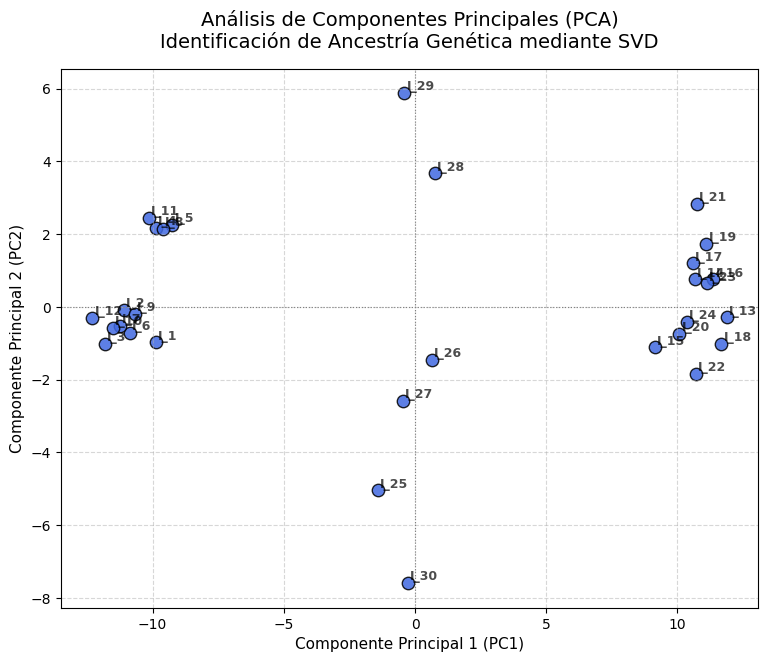

In [4]:
                                        #LIBRERIAS.
import numpy as np
import pandas as pd
import io
from google.colab import files
import matplotlib.pyplot as plt

                                      #CODIGO.
#Lectura de .csv.
print("Por favor, selecciona el archivo 'datos_genotipo.csv' desde tu computadora:")

archivos_subidos = files.upload()#Buscador de archivos de colab.

nombre_archivo = list(archivos_subidos.keys())[0]

df = pd.read_csv(io.BytesIO(archivos_subidos[nombre_archivo]))
G = df.values
n, m = G.shape #Obtener n (individuos) y m (SNPs) de G
print(f"Archivo procesado: {nombre_archivo}")
print(f"Número de individuos: {n}")
print(f"Número de SNPs: {m}") # m va a dar m+1 ya que esta tomando la colunma que dice individuo #
#Final de lectura.
print("Lectura Completada...")

#Estimación de frecuencia y limpieza.

  #Como la matriz real tiene string voy a realizar una limpienza para poder pasarle la formula, ya sabemos que la primera fila representa el individuo 1 y asi en secuencia.

Matriz_G = G[:, 1:].astype(int)
m = m-1 # parchamos la dimension de m ya que le quite una columna(individuo #). <-------------------------------------------
p = np.sum(Matriz_G, axis=0) / (2 * n) #Sumamos cada columna y le aplicamos la formula del enunciado.

  #Ahora verificamos cuales son validos, para eso se crea una tolerancia maxima y minima; un numero muy pequeño y uno muy cercano a uno. En mi caso voy a tomar 1e-5

validos = (p > 1e-5) & (p < (1 - 1e-5))

Matriz_G_Verificada = Matriz_G[:, validos]
p_Verificada = p[validos]

snps_Eliminados= (m) - Matriz_G_Verificada.shape[1] #Por si queremos ver la cantidad de eliminados.

print("Estimación y Limpieza Completado...")


#Normalización de Patterson...

  #Aplicaremos la formula para obtener la matriz G(cosito arriba).
  #Por legibilidad del codigo separare la division.

num = Matriz_G_Verificada - 2*p_Verificada #numerador.
den = np.sqrt(2 * p_Verificada * (1 - p_Verificada)) #denominador.

G_Cosito = num / den # nueva matriz a la que le aplicamos la formula.

print("Normalización de Patterson Completada....")


#Factorización y Proyección....

  #Ahora pasamos a calcular la SVD.

U, S, Vt = np.linalg.svd(G_Cosito, full_matrices=False)

  # Y nos dicen que PC es la multiplicacion de U por sigma, en este caso S.

PC = U * S

print("Factorización SVD Completada...")

#Graficación de PC_1 y PC_2

  #Se extrae la componente principal de todos los individuos
pc1 = PC[:, 0]
pc2 = PC[:, 1]

#Y se grafica.
plt.figure(figsize=(9, 7))

plt.scatter(pc1, pc2, color='royalblue', edgecolors='k', s=80, alpha=0.85, label='Individuos')


for i in range(len(pc1)):
    plt.text(pc1[i] + 0.08, pc2[i] + 0.08, f"I_{i+1}", fontsize=9, weight='semibold', alpha=0.7)

plt.axhline(0, color='gray', linestyle=':', linewidth=0.8)
plt.axvline(0, color='gray', linestyle=':', linewidth=0.8)


plt.title("Análisis de Componentes Principales (PCA)\nIdentificación de Ancestría Genética mediante SVD", fontsize=14, pad=15)
plt.xlabel("Componente Principal 1 (PC1)", fontsize=11)
plt.ylabel("Componente Principal 2 (PC2)", fontsize=11)


plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig("mapa_ancestria.pdf", bbox_inches='tight', dpi=300)

plt.show()